In [60]:
"""
Multiple Company Portfolio Analysis

Purpose:
    This script analyzes a user-defined portfolio of different stocks. It asks
    the user to enter company names or ticker symbols, confirms the matched
    Yahoo Finance tickers, downloads historical market data, calculates price
    and return metrics, and produces visual illustrations for comparing the
    selected companies. It also builds weighted portfolio simulations so the
    user can evaluate portfolio value, risk, return, Sharpe ratio, and the
    efficient frontier.

Table of Contents:
    A. User Inputs, Ticker Confirmation, Market Data Download, and Summary Metrics
       A1. Ask how many companies the user wants to analyze
       A2. Collect and confirm company names or ticker symbols
       A3. Collect and validate the historical date range
       A4. Download adjusted close prices for all selected tickers
       A5. Calculate daily percentage returns
       A6. Combine prices and returns into one exportable dataset
       A7. Generate descriptive statistics for prices and returns
       A8. Identify maximum prices and maximum daily returns

    B. Interactive Price and Return Line Charts
       B1. Define the reusable Plotly charting function
       B2. Plot adjusted close prices and daily returns

    C. Daily Return Distribution Analysis
       C1. Create an interactive histogram to compare return behavior and volatility

    D. Correlation and Relationship Analysis
       D1. Build an interactive correlation heatmap of daily returns
       D2. Create a Seaborn pairplot for return relationships

    E. Scaled Price Comparison
       E1. Normalize stock prices to their starting values for relative growth comparison

    F. Random Portfolio Weight Generation
       F1. Generate random asset weights that sum to 100%

    G. Portfolio Weight Visualization
       G1. Display the random portfolio allocation as a pie chart

    H. Weighted Portfolio Backtest
       H1. Apply asset weights to historical prices
       H2. Ask for the user's total investment amount
       H3. Calculate weighted portfolio values and returns
       H4. Plot total portfolio value over time
       H5. Plot individual weighted company contributions
       H6. Plot portfolio daily return over time

    I. Quantitative Analytics Engine
       I1. Calculate annual return, volatility, Sharpe ratio, final value, and ROI
       I2. Compare random-weight and equal-weight portfolio metrics

    J. Monte Carlo Portfolio Simulation
       J1. Run many random portfolio allocations and store the resulting metrics

    K. Optimal Portfolio and Efficient Frontier
       K1. Find the highest-Sharpe portfolio and visualize the efficient frontier
"""

"\nMultiple Company Portfolio Analysis\n\nPurpose:\n    This script analyzes a user-defined portfolio of different stocks. It asks\n    the user to enter company names or ticker symbols, confirms the matched\n    Yahoo Finance tickers, downloads historical market data, calculates price\n    and return metrics, and produces visual illustrations for comparing the\n    selected companies. It also builds weighted portfolio simulations so the\n    user can evaluate portfolio value, risk, return, Sharpe ratio, and the\n    efficient frontier.\n\nTable of Contents:\n    A. User Inputs, Ticker Confirmation, Market Data Download, and Summary Metrics\n       A1. Ask how many companies the user wants to analyze\n       A2. Collect and confirm company names or ticker symbols\n       A3. Collect and validate the historical date range\n       A4. Download adjusted close prices for all selected tickers\n       A5. Calculate daily percentage returns\n       A6. Combine prices and returns into one expo

In [61]:
#Import key libraries and Modules
from matplotlib import ticker # This is needed to fix the ticker error in the distribution plot section
import pandas as pd # For data manipulation and analysis
import numpy as np # For numerical operations
import datetime as dt # For handling date and time data
import yfinance as yf # For fetching financial data from Yahoo Finance
import matplotlib.pyplot as plt # For plotting static graphs
import seaborn as sns # For enhanced data visualization, especially for the pairplot
import plotly.express as px # For creating interactive plots easily
import plotly.graph_objects as go # For more complex interactive visualizations
from plotly.subplots import make_subplots # For creating subplot layouts in Plotly
import os # For handling file paths and directories
import webbrowser # For opening saved HTML files in the default web browser

# Setup the exact target folder destination path [CHANGE THIS TO YOUR OWN FOLDER PATH]
output_folder = "d:/Alimardon/Python/Capstone Project/Multicompany analysis"
os.makedirs(output_folder, exist_ok=True)
# == THIS CODE IS INTENDED TO ANALYZE MULTIPLE COMPANIES SIMULTANEOUSLY. ==
# ==THE CODE PROMPTS THE USER TO ENTER COMPANY NAMES, DATES COVERED == 


In [62]:
# A Let's begin by asking the user how many companies they want to analyze, and then we will loop through that number to collect the company names or ticker symbols. We will use yfinance to search for the ticker symbol and exact company name, and ask the user to confirm if the match is correct before saving it to a list.
# A1. Ask the user how many companies they want to analyze
# This loop keeps running until a valid integer is entered
companies_list = []
while True:
    try:
        num_companies_input = input("How many companies do you want to analyze? (Enter a number): ").strip()
        num_companies = int(num_companies_input)
        # Optional check: Ensure they didn't enter 0 or a negative number
        if num_companies <= 0:
            print("[NOTICE] The number must be greater than 0. Please try again.")
            continue
        # If we got a valid positive integer, we can break out of the loop and proceed to collect company names
        break  # Success! Valid number received, exit the input loop
    except ValueError: # This catches letters, spaces, or symbols that cannot be turned into an integer
        print(f"[NOTICE] '{num_companies_input}' is not a valid number. Please enter a whole number (e.g., 3).")


[NOTICE] '' is not a valid number. Please enter a whole number (e.g., 3).
[NOTICE] '' is not a valid number. Please enter a whole number (e.g., 3).
[NOTICE] '' is not a valid number. Please enter a whole number (e.g., 3).


In [63]:

# A2. Loop through the number of companies to collect their names/tickers
# A set of common English affirmative answers in lowercase. We will need them to handle user confirmations in a flexible way. 
# Since we convert inputs to lowercase, any capitalization variation (e.g., "YES", "Exactly") works automatically.
AFFIRMATIVES = {"y", "yes", "yeah", "yep", "yea", "yup", "ja", "ok", "okay", "sure", 
    "correct", "affirmative", "exactly", "that's right", "thats right", 
    "you got it", "right on", "absolutely", "definitely", "indeed", 
    "totally", "right", "true", "perfect", "fine", "certainly"}
i = 0
while i < num_companies:
    while True:
        # Dynamic instruction string changes if there is a previous entry to return to
        back_instruction = " (or type 'back' to return to previous entry)" if i > 0 else ""
        # Prompt the user for the company name or ticker symbol, including the dynamic back instruction if applicable
        company_input = input(f"\n[{i+1}/{num_companies}] Enter the company name or ticker symbol{back_instruction} (e.g., Apple (AAPL), Microsoft (MSFT), Tesla (TSLA)): ").strip()
        # Handle the 'back' command to allow the user to return to the previous entry if they want to correct it
        if company_input.lower() == "back":
            if i > 0:
                print(f"\n [RETURNING] Going back to modify entry #{i}...")
                companies_list.pop()  # Remove the last confirmed entry
                i -= 1                 # Decrement the outer loop index counter
                break                  # Break out of inner loop to restart the prompt for the adjusted index
            else:
                print("   [NOTICE] You are already on the first entry. Cannot go back.") # In case the user knows the 'back' command but tries to use it on the first entry, we will just notify them and continue with the normal flow without decrementing or popping since there is nothing to go back to.
                continue # Restart the inner loop to ask for the first company again
        # If they didn't type 'back', we proceed with the normal search and confirmation process
        try:
            # Run the Yahoo Finance lookup
            search_result = yf.Search(company_input, max_results=1)
            # Check if the result exists
            if not search_result.quotes or len(search_result.quotes) == 0:
                print(f"[NOTICE] Could not find any ticker for '{company_input}'. Please check your spelling and try again.")
                continue # Restart the loop to ask for a new input
            # Properly extract the first match dictionary object using [0]
            first_match = search_result.quotes[0]
            # Ensure a trading symbol was actually returned
            if "symbol" not in first_match:
                print(f" [NOTICE] Data found for '{company_input}' is incomplete. Please try another variant of the name or ticker symbol." )
                continue # Restart the loop to ask for a new input
            # Extract the ticker symbol from the first match
            ticker_symbol = first_match["symbol"]
            # DUPLICATE CHECK: Before we proceed to confirmation, let's check if this ticker has already been added to our companies_list to avoid duplicates in our analysis.   
            # Create a quick list of all tickers already saved in your data list
            existing_tickers = [company["ticker"] for company in companies_list]
            if ticker_symbol in existing_tickers:
                print(f" [NOTICE] '{ticker_symbol}' has already been added to your analysis list. Duplicates might not serve a purpose. Please enter a different company.")
                continue  # Restarts the inner loop to ask for a new input
            # Extract the exact company name safely with fallbacks
            exact_company_name = (
                first_match.get("longName")
                or first_match.get("shortName")
                or first_match.get("name")
                or company_input) # If none of the expected name fields are available, we will just use the original input as a last resort to ensure we have something to display and save.
            # ASK OPERATOR FOR CONFIRMATION
            print(f"System matched your input to: '{exact_company_name}' ({ticker_symbol})")
            # We will check the operator's confirmation against a set of common affirmative responses in lowercase, so we can handle variations like "YES", "Yes", "Y", etc. without needing to list every capitalization form. We will also strip any extra spaces just in case.
            confirm = input("Is this the company name and ticker you meant? (y/n): ").strip().lower()
            # If the confirmation response is not in our set of affirmatives, we will assume they meant "no" and prompt them to try again with different keywords.
            if confirm not in AFFIRMATIVES:
                print(f" [NOTICE] Got it. Let's try searching for '{company_input}' again with different keywords.")
                continue  # Go back to the top of the while loop and ask again
            # Package and save to list if confirmed
            company_data = {"ticker": ticker_symbol, "name": exact_company_name}
            companies_list.append(company_data)
            print(f"-> Successfully confirmed and added: {exact_company_name} ({ticker_symbol})")
            i += 1  # Successfully advanced, increment company count index
            break   # Break inner loop to prompt for the next company index number
        # Catch any unexpected exceptions during the search and confirmation process to prevent crashes and allow the user to try again    
        except Exception as e:
            print(f"[NOTICE] Connection error: {e}. Let's try that entry again.")
            continue # Restart the inner loop to ask for the same company index again after an error
# Print the final compiled results outside the loop
print("\n--- Final Collected List ---")
print(companies_list)
ticker_list = [company["ticker"] for company in companies_list]
ticker_name_map = {company["ticker"]: company["name"] for company in companies_list}


[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spelling and try again.
[NOTICE] Could not find any ticker for ''. Please check your spel

In [64]:

# A.3 Let's prompt the user to enter the start and end dates for the stock data they want to analyze. We will use these dates to fetch the historical stock data for all the companies they entered.
while True:
    start_date_input = input("\nEnter the start date for the stock data (YYYY-MM-DD): ").strip()
    end_date_input = input("Enter the end date for the stock data (YYYY-MM-DD): ").strip()
    try: # Validate date format and logical order
        start_date = dt.datetime.strptime(start_date_input, "%Y-%m-%d") # This will raise a ValueError if the format is incorrect
        end_date = dt.datetime.strptime(end_date_input, "%Y-%m-%d") # This will raise a ValueError if the format is incorrect
        if start_date >= end_date: # Check if the start date is before the end date
            print("[NOTICE] Start date must be earlier than end date. Please try again.")
            continue # Restart the loop to ask for the dates again
        break  # Dates are valid, exit the loop
    except ValueError: # This catches any issues with date parsing, such as incorrect format or invalid calendar dates
        print(f" [NOTICE] One or both of the dates you entered are not in the correct format. Please use YYYY-MM-DD and try again.")
print(f"\nDownloading collective database for: {ticker_list}...")


In [65]:

# A.4 Download data for all tickers simultaneously
stock = yf.download(
    ticker_list,
    start=start_date,
    end=end_date,
    multi_level_index=True,  # Crucial for organizing multi-company data frames
    auto_adjust=False) # We will handle adjustments manually if needed, so we want the raw data
# Extract only the Adjusted Closing prices for all companies
# This yields a DataFrame where each column represents a company ticker
adj_close_df = stock["Adj Close"]
# Safety catch: If the operator only entered 1 company, force pandas to keep it as a DataFrame
if isinstance(adj_close_df, pd.Series):
    adj_close_df = adj_close_df.to_frame(name=ticker_list[0])
# Let's carry out some data curation steps to ensure our dataset is clean and ready for analysis. We will handle missing data by forward-filling and backward-filling, which is common practice for stock price data to maintain continuity across non-trading days and holidays. This way, we can avoid gaps in our visualizations and calculations that could arise from missing dates.
# Forward-fill missing prices (carries the last known price to non-trading days/holidays)
adj_close_df = adj_close_df.ffill()
# Backward-fill remaining blanks (handles assets starting mid-way through your date range)
adj_close_df = adj_close_df.bfill()
print("\n--- Master Adjusted Close Prices DataFrame (Head) ---")
print(adj_close_df.head())


[*********************100%***********************]  5 of 5 completed


--- Master Adjusted Close Prices DataFrame (Head) ---
Ticker      0P0001CO79.F        AAPL  BITCH-USD  FTMX-USD  PUSSY-USD
Date                                                                
2025-01-01    277.350006  242.301926   0.037689   0.01754   0.000006
2025-01-02    277.350006  242.301926   0.037689   0.01754   0.000007
2025-01-03    277.470001  241.815033   0.037689   0.01754   0.000007
2025-01-04    277.470001  241.815033   0.037689   0.01754   0.000007
2025-01-05    277.470001  241.815033   0.037689   0.01754   0.000007


In [66]:

# A.5 Calculate returns
daily_returns_df = adj_close_df.pct_change(1) * 100 # Convert to percentage for easier interpretation
daily_returns_df = daily_returns_df.fillna(0) # Replace the first row of NaN returns with 0% since there is no previous day to compare to
print("\n--- Master Daily Returns DataFrame (Head) ---")
print(daily_returns_df.head())



--- Master Daily Returns DataFrame (Head) ---
Ticker      0P0001CO79.F      AAPL  BITCH-USD  FTMX-USD  PUSSY-USD
Date                                                              
2025-01-01      0.000000  0.000000        0.0       0.0   0.000000
2025-01-02      0.000000  0.000000        0.0       0.0  16.666664
2025-01-03      0.043265 -0.200945        0.0       0.0   0.000000
2025-01-04      0.000000  0.000000        0.0       0.0   0.000000
2025-01-05      0.000000  0.000000        0.0       0.0   0.000000


In [67]:

# A.6 Let's combine the adjusted close prices and daily returns into a single DataFrame for easier comparison and to facilitate any future combined analyses. 
# Prepare temporary copies with renamed headers to distinguish prices from returns
price_temp_df = adj_close_df.add_prefix("Price: ")
returns_temp_df = daily_returns_df.add_prefix("Return: ")
# Combine both DataFrames side-by-side along columns (axis=1)
combined_market_df = pd.concat([price_temp_df, returns_temp_df], axis=1)
# Save the combined DataFrame directly into your target folder path
csv_combined_filename = os.path.join(output_folder, "combined_prices_and_returns.csv")
combined_market_df.to_csv(csv_combined_filename, index=True)
print(f"[SUCCESS] Saved Combined Market DataFrame to CSV at: {csv_combined_filename}")


[SUCCESS] Saved Combined Market DataFrame to CSV at: d:/Alimardon/Python/Capstone Project/Multicompany analysis\combined_prices_and_returns.csv


In [68]:

# A.7 Generate the standard descriptive statistics table
# Calculate descriptive statistics separately for prices and returns to maintain clarity
price_summary = adj_close_df.describe().round(2)
return_summary = daily_returns_df.describe().round(2)
# Prefix row indexes to avoid naming collisions
price_summary.index = [f"Price {idx}" for idx in price_summary.index]
return_summary.index = [f"Return {idx}" for idx in return_summary.index]
# Stack them vertically into one clean table
summary_stats_df = pd.concat([price_summary, return_summary])
# Combine folder path with filename for summary table
html_stats_filename = os.path.join(output_folder, "portfolio_statistical_summary.html")
# Convert the DataFrame to an HTML file inside the folder
summary_stats_df.to_html(html_stats_filename, classes="table table-striped table-hover", border=0)
print(f"\n[SUCCESS] Compiled complete summary stats to: {html_stats_filename}")
# Explicitly print the summary dataframe to your terminal screen
print("\n--- Summary Statistics Table ---")
print(summary_stats_df)
# Optionally, open the saved HTML file in the default web browser for a nicer view of the statistics table
webbrowser.open(f"file://{os.path.abspath(html_stats_filename)}")



[SUCCESS] Compiled complete summary stats to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\portfolio_statistical_summary.html

--- Summary Statistics Table ---
Ticker        0P0001CO79.F    AAPL  BITCH-USD  FTMX-USD  PUSSY-USD
Price count         365.00  365.00     365.00    365.00     365.00
Price mean          300.87  231.21       0.04      0.03       0.00
Price std            17.62   26.59       0.00      0.02       0.00
Price min           259.40  171.51       0.03      0.02       0.00
Price 25%           283.20  209.18       0.04      0.02       0.00
Price 50%           307.24  229.38       0.04      0.02       0.00
Price 75%           315.61  251.58       0.04      0.02       0.00
Price max           326.40  285.66       0.06      0.13       0.00
Return count        365.00  365.00     365.00    365.00     365.00
Return mean           0.05    0.05       0.06      0.24       0.08
Return std            0.70    1.69       2.89      6.51       7.45
Return min           

True

In [69]:

# A.8 Let's also extract and print the maximum price and return for each company to highlight the peaks in our dataset. This can be useful for quick insights and comparisons.
max_price = adj_close_df.max().round(2)
max_return = daily_returns_df.max().round(2)
print("\n--- Maximum Prices ---")
print(max_price)
print("\n--- Maximum Returns ---")
print(max_return)



--- Maximum Prices ---
Ticker
0P0001CO79.F    326.40
AAPL            285.66
BITCH-USD         0.06
FTMX-USD          0.13
PUSSY-USD         0.00
dtype: float64

--- Maximum Returns ---
Ticker
0P0001CO79.F     3.02
AAPL            15.33
BITCH-USD       15.69
FTMX-USD        74.56
PUSSY-USD       33.33
dtype: float64


In [70]:

# B.1 Now that we have our data prepared and some key statistics calculated, we can move on to creating visualizations to compare the stock price movements and return distributions across the companies. We will create interactive line charts for the adjusted close prices and daily returns, as well as a distribution plot for the returns to see how they compare in terms of volatility and overall behavior.
def plot_finance_data(df, title, output_folder, save_html=True):
    # Initialize the base line plot
    fig = px.line(title=title)
    # Loops over every column provided in the DataFrame
    for i in df.columns:
        fig.add_scatter(x=df.index, y=df[i], name=i)
    # Style modifications applied to the figure globally
    fig.update_traces(line=dict(width=2))
    fig.update_layout({"plot_bgcolor": "white"})
    # Clean file name generation
    base_filename = (title.lower().replace(" ", "_").replace("(", "").replace(")", ""))
    png_filename = f"{base_filename}.png"
    html_filename = f"{base_filename}.html"
    # Combine the output_folder path with the filenames securely
    png_output_path = os.path.join(output_folder, png_filename)
    html_output_path = os.path.join(output_folder, html_filename)
    # Save the high-res static PNG image in the specified folder
    fig.write_image(png_output_path, width=1200, height=600, scale=3)
    print(f" Saved chart image directly to folder: {png_output_path}")
    # Save the interactive graph as an HTML file in the specified folder
    if save_html:        
        fig.write_html(html_output_path)
        print(f" Saved interactive HTML chart to folder: {html_output_path}")
    fig.show()


In [71]:

#  B.2  Let's create interactive line charts for the adjusted close prices and daily returns.
plot_finance_data(adj_close_df, "Adjusted Close Price Comparison", output_folder)
plot_finance_data(daily_returns_df, "Daily Return Comparison", output_folder)


 Saved chart image directly to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\adjusted_close_price_comparison.png
 Saved interactive HTML chart to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\adjusted_close_price_comparison.html


 Saved chart image directly to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\daily_return_comparison.png
 Saved interactive HTML chart to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\daily_return_comparison.html


In [72]:

# B.3 Now let's create a distribution plot for the daily returns of all companies to compare their volatility and return behavior. 
# Melt the DataFrame so Plotly can read the columns as categories. We will reset the index to turn the date into a column, and then use the melt function to create a long-format DataFrame where we have one column for the company name (which will be used for coloring) and one column for the daily return values. This format is ideal for creating a distribution plot with Plotly Express.
melted_returns = daily_returns_df.reset_index().melt(
    id_vars=daily_returns_df.index.name or "Date",
    var_name="Company",
    value_name="Daily Return (%)")
# Create an interactive, high-precision distribution plot
fig_density = px.histogram(
    melted_returns,
    x="Daily Return (%)",
    color="Company",
    title="Precise Distribution of Daily Returns",
    barmode="overlay",
    opacity=0.4,
    nbins=200  # Creates tiny bars that form a smooth distribution shape
)
# Layout configuration updated with valid axis font properties
fig_density.update_layout(
    plot_bgcolor="white",
    title=dict(font=dict(size=14)),
    xaxis=dict(
        showgrid=True, 
        gridcolor="lightgray", 
        range=[-5, 5], 
        tickfont=dict(size=10),       # Valid property for axis numbers
        title=dict(text="Daily Return (%)", font=dict(size=11))  # Valid property for label
    ),
    yaxis=dict(
        showgrid=True, 
        gridcolor="lightgray", 
        tickfont=dict(size=10),       # Valid property for axis numbers
        title=dict(text="Frequency", font=dict(size=11))         # Valid property for label
    ),
    legend=dict(font=dict(size=9))
)
fig_density.update_traces(marker=dict(line=dict(width=0.5)))
# Save as an interactive HTML file
density_html_path = os.path.join(output_folder, "precise_returns_distribution.html")
fig_density.write_html(density_html_path)
print(f" [SUCCESS] Saved interactive distribution chart to: {density_html_path}")
# Display the interactive graph
fig_density.show()

 [SUCCESS] Saved interactive distribution chart to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\precise_returns_distribution.html


In [73]:

# D.1 INTERACTIVE CORRELATION HEATMAP (PLOTLY)
# Calculate the correlation matrix safely
correlation_matrix = daily_returns_df.corr(numeric_only=True)
# Changed "coolwarm" to "RdBu_r" to use a valid Plotly financial color scale
fig_heatmap = px.imshow(
    correlation_matrix,
    text_auto=".2f", # Automatically overlays the correlation values rounded to 2 decimals
    color_continuous_scale="RdBu_r", # Clean Red-to-Blue divergent scaling
    title="Correlation Matrix of Daily Company Returns",
    aspect="auto" # Allows the blocks to resize intelligently when you stretch the window
)
# Shrink fonts and configure auto-scaling so it scales down beautifully
fig_heatmap.update_layout(
    plot_bgcolor="white",
    title=dict(font=dict(size=14)),
    xaxis=dict(tickfont=dict(size=10)),
    yaxis=dict(tickfont=dict(size=10)),
    coloraxis_showscale=False # Hides the side color bar to give the matrix more breathing room
)
# Apply font scaling directly to the inside numbers so they shrink with the boxes
fig_heatmap.update_traces(textfont=dict(size=11))
# Save as an interactive HTML file
heatmap_stats_filename = os.path.join(output_folder, "company_returns_correlation_heatmap.html")
fig_heatmap.write_html(heatmap_stats_filename)
print(f" [SUCCESS] Saved interactive correlation heatmap to: {heatmap_stats_filename}")
# Display the interactive heatmap
fig_heatmap.show()


 [SUCCESS] Saved interactive correlation heatmap to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\company_returns_correlation_heatmap.html


 [SUCCESS] Saved returns pairplot image to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\returns_pairplot.png


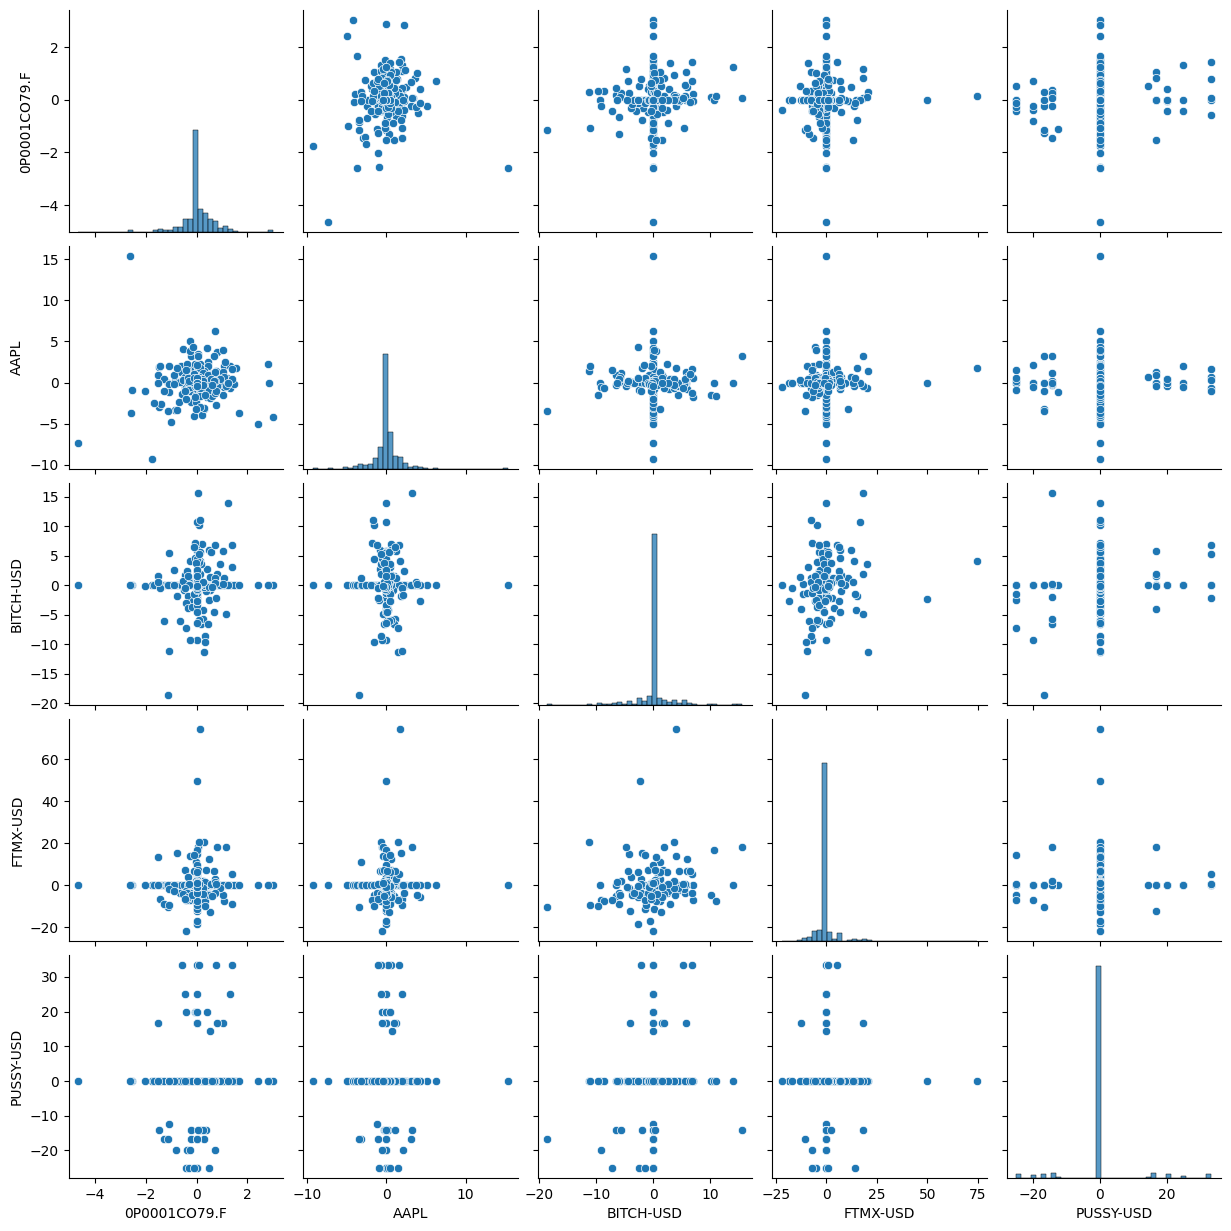

In [74]:
# D.2 Let's display now pairplot between the returns of the companies to see if there are any interesting relationships. We will use seaborn for this and save it as a high-resolution image.
sns.pairplot(daily_returns_df)
pairplot_filename = os.path.join(output_folder, "returns_pairplot.png")
plt.savefig(pairplot_filename, dpi=300)
print(f" [SUCCESS] Saved returns pairplot image to: {pairplot_filename}")
plt.show()

In [75]:
# Function to scale stock prices to based on their initial starting price, so we can compare their relative growth over time
def scale_prices(raw_prices_df):
    scaled_prices_df = raw_prices_df.copy()
    for i in raw_prices_df.columns:  # Iterate over each company column
        initial_price = raw_prices_df[i].iloc[0]
        scaled_prices_df[i] = (raw_prices_df[i] / initial_price) 
    return scaled_prices_df
scaled_prices_df = scale_prices(adj_close_df)
scaled_prices_df.head()


Ticker,0P0001CO79.F,AAPL,BITCH-USD,FTMX-USD,PUSSY-USD
Date,,,,,
2025-01-01,1.000000,1.000000,1.0,1.0,1.000000
2025-01-02,1.000000,1.000000,1.0,1.0,1.166667
2025-01-03,1.000433,0.997991,1.0,1.0,1.166667
2025-01-04,1.000433,0.997991,1.0,1.0,1.166667
2025-01-05,1.000433,0.997991,1.0,1.0,1.166667


In [76]:
#Save the scaled prices DataFrame to a CSV file in the output folder
csv_scaled_filename = os.path.join(output_folder, "scaled_stock_prices.csv")
scaled_prices_df.to_csv(csv_scaled_filename, index=True)
print(f" [SUCCESS] Saved scaled stock prices to CSV at: {csv_scaled_filename}")
print("\n--- Scaled Stock Prices DataFrame (Head) ---")
print(scaled_prices_df.head())
plot_finance_data(scaled_prices_df, "Scaled Stock Price Comparison", output_folder)

 [SUCCESS] Saved scaled stock prices to CSV at: d:/Alimardon/Python/Capstone Project/Multicompany analysis\scaled_stock_prices.csv

--- Scaled Stock Prices DataFrame (Head) ---
Ticker      0P0001CO79.F      AAPL  BITCH-USD  FTMX-USD  PUSSY-USD
Date                                                              
2025-01-01      1.000000  1.000000        1.0       1.0   1.000000
2025-01-02      1.000000  1.000000        1.0       1.0   1.166667
2025-01-03      1.000433  0.997991        1.0       1.0   1.166667
2025-01-04      1.000433  0.997991        1.0       1.0   1.166667
2025-01-05      1.000433  0.997991        1.0       1.0   1.166667
 Saved chart image directly to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\scaled_stock_price_comparison.png
 Saved interactive HTML chart to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\scaled_stock_price_comparison.html


In [77]:

#Let's create an array that holds random portfolio weights
# Note that portfolio weights must add up to 1
import random
# F.1 Let's create an array that holds random portfolio weights
# Note that portfolio weights must add up to 1
def generate_random_weights(num_assets):
    weights_random = []
    for i in range(num_assets):
        weights_random.append(random.random()) 
    #Let's make the num of all weight add up to 1 by dividing each weight by the total sum of weights
    weights_random = np.array(weights_random)
    weights_random = weights_random / np.sum(weights_random)  # Normalize to sum to 1
    return weights_random
weights_random = generate_random_weights(len(ticker_list))
print("\n--- Randomly Generated Portfolio Weights ---")
print(weights_random)


--- Randomly Generated Portfolio Weights ---
[0.31420023 0.06089811 0.12274751 0.46731492 0.03483924]


 [SUCCESS] Saved portfolio weights pie chart to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\random_portfolio_weights_distribution.png


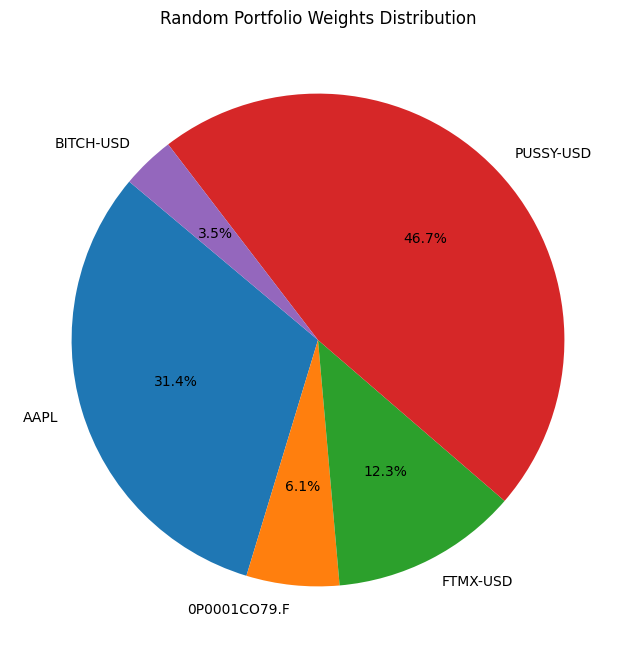

In [78]:

#Let's build a pie chart to visualize the distribution of the portfolio weights across the companies. We will use matplotlib for this and save it as a high-resolution image.
plt.figure(figsize=(8, 8))
plt.pie(weights_random, labels=ticker_list, autopct='%1.1f%%', startangle=140)
plt.title("Random Portfolio Weights Distribution")
# Save the pie chart image in the output folder
pie_chart_filename = os.path.join(output_folder, "random_portfolio_weights_distribution.png")
plt.savefig(pie_chart_filename, dpi=300)
print(f" [SUCCESS] Saved portfolio weights pie chart to: {pie_chart_filename}")
plt.show()


In [79]:
# H.1 Now let's apply the random weights to the scaled stock prices to see how a portfolio with those weights would have performed over time. 
# We will calculate the weighted returns of each company and then sum them up to get the total portfolio return over time. 
# We will also calculate the daily return of the portfolio to see its volatility.
def asset_allocation(df, weights, total_investment):
    portfolio_df = df.copy()
    scaled_df = scale_prices(df)  # Scale the prices to get percentage growth
    for i, ticker in enumerate(scaled_df.columns):
        portfolio_df[ticker] = scaled_df[ticker] * weights[i] * (total_investment)
    portfolio_df['Portfolio Value [$]'] = portfolio_df.sum(axis=1, numeric_only=True)  # Sum across all companies to get total portfolio value
    portfolio_df['Portfolio Daily Return [%]'] = portfolio_df['Portfolio Value [$]'].pct_change(1).fillna(0) * 100  # Calculate daily return of the portfolio
    return portfolio_df
# H.2 Let's prompt the user to enter the total amount of money they want to invest in this portfolio, and ensure it's a valid number greater than 0 before proceeding with the calculations.
while True:
    total_investment_input = input("\nEnter the total amount of money you want to invest in this portfolio (e.g., 10000): ").strip()
    try:
        total_investment = float(total_investment_input)
        if total_investment <= 0:
            print("[NOTICE] The investment amount must be greater than 0. Please try again.")
            continue
        break
    except ValueError:
        print(f"[NOTICE] '{total_investment_input}' is not a valid number. Please enter a numeric value (e.g., 10000).")
# H.3Now that we have the total investment amount and the random weights, we can calculate the portfolio returns over time.
portfolio_df = asset_allocation(adj_close_df, weights_random, total_investment)
portfolio_df = portfolio_df.round(2)
# Save the weighted returns DataFrame to a CSV file in the output folder
portfolio_df_filename = os.path.join(output_folder, "weighted_portfolio_returns.csv")
portfolio_df.to_csv(portfolio_df_filename, index=True)
print(f" [SUCCESS] Saved weighted portfolio returns to CSV at: {portfolio_df_filename}")
print("\n--- Weighted Portfolio Returns DataFrame (Head) ---")
print(portfolio_df.head())

 [SUCCESS] Saved weighted portfolio returns to CSV at: d:/Alimardon/Python/Capstone Project/Multicompany analysis\weighted_portfolio_returns.csv

--- Weighted Portfolio Returns DataFrame (Head) ---
Ticker      0P0001CO79.F  AAPL  BITCH-USD  FTMX-USD  PUSSY-USD  \
Date                                                             
2025-01-01          0.31  0.06       0.12      0.47       0.03   
2025-01-02          0.31  0.06       0.12      0.47       0.04   
2025-01-03          0.31  0.06       0.12      0.47       0.04   
2025-01-04          0.31  0.06       0.12      0.47       0.04   
2025-01-05          0.31  0.06       0.12      0.47       0.04   

Ticker      Portfolio Value [$]  Portfolio Daily Return [%]  
Date                                                         
2025-01-01                 1.00                        0.00  
2025-01-02                 1.01                        0.58  
2025-01-03                 1.01                        0.00  
2025-01-04                 1.

In [80]:
# H.4 Let's plot the total portfolio value over time to see how the portfolio performed based on the random weights and total investment. This will give us a visual representation of the growth of our investment over the selected time period.
plot_finance_data(portfolio_df[['Portfolio Value [$]']], "Portfolio Value Over Time", output_folder) 

 Saved chart image directly to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\portfolio_value_over_time.png
 Saved interactive HTML chart to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\portfolio_value_over_time.html


In [81]:
# H.5 Let's also plot the individual weighted returns of each company in the portfolio to see how each one contributed to the overall portfolio return over time.
plot_finance_data(portfolio_df[ticker_list], "Individual Weighted Returns of Portfolio Companies", output_folder)

 Saved chart image directly to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\individual_weighted_returns_of_portfolio_companies.png
 Saved interactive HTML chart to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\individual_weighted_returns_of_portfolio_companies.html


In [82]:
# H.6 Let's calculate the portfolio daily return by taking the percentage change of the total portfolio value over time, and then plot it to see the volatility of the portfolio.
portfolio_df["Portfolio Daily Return [%]"] = portfolio_df["Portfolio Value [$]"].pct_change(1).fillna(0) * 100
plot_finance_data(portfolio_df[["Portfolio Daily Return [%]"]], "Portfolio Daily Return [%] Over Time", output_folder)

 Saved chart image directly to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\portfolio_daily_return_[%]_over_time.png
 Saved interactive HTML chart to folder: d:/Alimardon/Python/Capstone Project/Multicompany analysis\portfolio_daily_return_[%]_over_time.html


In [83]:
# ==============================================================================
# I.1 QUANTITATIVE ANALYTICS ENGINE & MACRO PERFORMANCE SIMULATION PIPELINE
# ==============================================================================
# Prompt for the baseline risk-free rate benchmark upfront.
# Capturing this as a global variable outside the function block prevents the script
# from opening duplicate input popups during the Monte Carlo matrix iterations.
Rf = float(input(
        "Please enter the annualized risk-free rate (e.g., 10-Year US Treasuries) as a decimal fraction (e.g., 0.0448 for 4.48%): "))
# ==============================================================================
# QUANTITATIVE ANALYSIS PIPELINE ENGINE
# ==============================================================================
def simulation_engine(weights, initial_investment):
    """Executes Modern Portfolio Theory (MPT) metrics, historical account backtesting,
    and exports trial records for a specific asset weight distribution vector.
    """
    # Step 1: Backtest daily account principal values using lower-level asset allocation modules
    portfolio_df = asset_allocation(adj_close_df, weights, initial_investment)
    # Step 2: Compute historical Net Return on Investment (ROI) scalar metrics
    # Evaluates absolute percentage growth from day-one principal to the final trading row
    return_on_investment = ((portfolio_df["Portfolio Value [$]"].iloc[-1]
 - portfolio_df["Portfolio Value [$]"].iloc[0])
        / portfolio_df["Portfolio Value [$]"].iloc[0]) * 100
    # Step 3: Convert raw visible percentage returns down to absolute mathematical decimal floats
    # This prevents risk metrics from blowing up by a factor of 10,000 during matrix calculations
    daily_returns_decimal = daily_returns_df / 100
    # Step 4: Compute Annualized Blended Portfolio Expected Return (Additive Property)
    # Aggregates weight-adjusted asset mean daily returns and scales linearly over a 252-day calendar year
    expected_portfolio_return = (np.sum(daily_returns_decimal.mean() * weights) * 252)
    # Step 5: Compute Annualized Asset Covariance Matrix
    # Generates a square table mapping the directional tracking and variance profiles of all company pairs
    covariance = daily_returns_decimal.cov() * 252
    # Step 6: Compute Annualized Portfolio Volatility (Standard Deviation)
    # Applies the Markowitz MPT core equation via NumPy matrix dot-multiplication.
    # Blends horizontal weights transposed (weights.T), the covariance matrix, and vertical weights.
    expected_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance, weights)))
    # Step 7: Evaluate the Sharpe Risk-Adjusted Excess Return Efficiency Ratio
    risk_free_rate = Rf  # Benches performance against the pre-loaded global Treasury principal yield input
    sharpe_ratio = (expected_portfolio_return - risk_free_rate) / expected_volatility
    # Step 8: Export the active trial performance logging records to a permanent text file
    simulation_results_filename = os.path.join(output_folder, "simulation_engine_results.txt")
    with open(simulation_results_filename, "w") as f:
        f.write(f"Expected Portfolio Annual Return: {expected_portfolio_return*100:.2f}%\n")
        f.write(f"Portfolio Standard Deviation (Volatility): {expected_volatility*100:.2f}%\n")
        f.write(f"Sharpe Ratio: {sharpe_ratio:.2f}\n")
        f.write(f"Final Portfolio Value: ${portfolio_df['Portfolio Value [$]'].iloc[-1]:,.2f}\n")
        f.write(f"Return on Investment: {return_on_investment:.2f}%\n")
    # Step 9: Package the 5 calculated scalar variables into a clean un-nested tuple container for output
    return (expected_portfolio_return,
        expected_volatility,
        sharpe_ratio,
        portfolio_df["Portfolio Value [$]"].iloc[-1],
        return_on_investment,)

  


In [84]:
# I.2 Let's test out the "simulation_engine" function and print out statistical metrics
# Define the initial investment amount
initial_investment = total_investment
portfolio_metrics = simulation_engine(weights_random, initial_investment)
print("\n--- Simulation Engine Test Metrics ---")
print(f"Expected PortfolioAnnual Return:  {portfolio_metrics[0]*100:.2f}%")
print(f"Portfolio Standard Deviation (Volatility):     {portfolio_metrics[1]*100:.2f}%")
print(f"Sharpe Ratio:            {portfolio_metrics[2]:.2f}")
print(f"Final Portfolio Value:   ${portfolio_metrics[3]:,.2f}")
print(f"Return on Investment:    {portfolio_metrics[4]:.2f}%")


--- Simulation Engine Test Metrics ---
Expected PortfolioAnnual Return:  34.94%
Portfolio Standard Deviation (Volatility):     50.26%
Sharpe Ratio:            0.62
Final Portfolio Value:   $1.17
Return on Investment:    16.71%


In [85]:
#I.3 Let's generate equal weights for each company in the portfolio to see how an equally weighted portfolio would have performed compared to the randomly weighted one. This will give us a baseline for comparison.
def generate_equal_weights(num_assets):
    equal_weight = 1 / num_assets
    weights_equal = np.array([equal_weight] * num_assets)
    return weights_equal
initial_investment = total_investment
weights_equal = generate_equal_weights(len(ticker_list))
portfolio_metrics_equal = simulation_engine(weights_equal, initial_investment)
print("\n--- Equal Weights Portfolio Metrics ---")
print(f"Expected Portfolio Annual Return:  {portfolio_metrics_equal[0]*100:.2f}%")
print(f"Portfolio Standard Deviation (Volatility):     {portfolio_metrics_equal[1]*100:.2f}%")
print(f"Sharpe Ratio:            {portfolio_metrics_equal[2]:.2f}")
print(f"Final Portfolio Value:   ${portfolio_metrics_equal[3]:,.2f}")
print(f"Return on Investment:    {portfolio_metrics_equal[4]:.2f}%")



--- Equal Weights Portfolio Metrics ---
Expected Portfolio Annual Return:  23.75%
Portfolio Standard Deviation (Volatility):     35.81%
Sharpe Ratio:            0.55
Final Portfolio Value:   $1.02
Return on Investment:    2.09%


In [86]:
# ==============================================================================
# J.1 MONTE CARLO SIMULATION CONFIGURATION & TRACKING MATRICES
# ==============================================================================
# Define the scale of the simulation and pull core portfolio variables
sim_runs = int(input("Please enter the number of simulations you would like run for portfolio optimization"))  # Total number of unique random portfolio allocations to test
initial_investment = (total_investment)  # Core cash principal passed from the user prompt
num_assets = len(ticker_list)  # Dynamically calculate the number of companies
# Pre-allocate memory using NumPy zero-arrays to track simulation trials efficiently
weights_runs = np.zeros((sim_runs, num_assets))  # 2D Matrix grid to store row-by-row asset weights
sharpe_ratio_runs = np.zeros(sim_runs)  # 1D Array to track risk-adjusted efficiency scores
expected_portfolio_returns_runs = np.zeros(sim_runs)  # 1D Array to track annualized expected returns
volatility_runs = np.zeros(sim_runs)  # 1D Array to track portfolio standard deviation (risk)
return_on_investment_runs = np.zeros(sim_runs)  # 1D Array to track net growth percentages (ROI)
final_value_runs = np.zeros(sim_runs)  # 1D Array to track final ending dollar valuations


In [87]:
# ==============================================================================
# CORE SIMULATION EXECUTION LOOP
# ==============================================================================
for i in range(sim_runs):
    # Step A: Generate a set of normalized weights that sum to exactly 1.0
    weights = generate_random_weights(num_assets)
    weights_runs[i, :] = (weights)  # Cache the current allocation array into the tracking matrix row
    # Step B: Pass the weights into the quantitative analysis simulation engine
    # The engine calculates, converts metrics, and returns 5 scalar values
    (expected_portfolio_returns_runs[i],
        volatility_runs[i],
        sharpe_ratio_runs[i],
        final_value_runs[i],
        return_on_investment_runs[i]) = simulation_engine(weights, initial_investment)
    # Step C: Log the trial data outputs directly to the terminal screen
    print("Simulation Run = {}".format(i))
    print("Weights = {}, Final Value = ${:.2f}, Sharpe Ratio = {:.2f}".format(weights_runs[i].round(3), final_value_runs[i], sharpe_ratio_runs[i]))
    print("\n")


Simulation Run = 0
Weights = [0.061 0.18  0.39  0.081 0.288], Final Value = $0.93, Sharpe Ratio = 0.36




In [88]:
# ==============================================================================
# DATA AGGREGATION & PIPELINE PROCESSING
# ==============================================================================
print("\n [SYSTEM] Compiling results into a single master dashboard...")
# 1. Structure the multi-column weights matrix into a structured DataFrame
weights_df = pd.DataFrame(weights_runs, columns=[f"{ticker} Weight" for ticker in ticker_list])
# 2. Structure the 5 performance metrics into a separate independent DataFrame
metrics_df = pd.DataFrame({"Expected Portfolio Return": expected_portfolio_returns_runs,
        "Volatility": volatility_runs,
        "Sharpe Ratio": sharpe_ratio_runs,
        "Final Value": final_value_runs,
        "Return on Investment": return_on_investment_runs,})
# 3. Consolidate the tables side-by-side (axis=1) into one comprehensive master table
final_sim_results_df = pd.concat([weights_df, metrics_df], axis=1)
# 4. Generate the export file path string and save the table permanently as a CSV file
csv_output_path = os.path.join(
    output_folder, "monte_carlo_simulation_results.csv")
final_sim_results_df.to_csv(csv_output_path, index=False)
print(f" [SUCCESS] Exported complete dataset to: {csv_output_path}")
# Preview the top 5 rows of the master table dataset within the notebook screen view
final_sim_results_df.head()



 [SYSTEM] Compiling results into a single master dashboard...
 [SUCCESS] Exported complete dataset to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\monte_carlo_simulation_results.csv


,AAPL Weight,0P0001CO79.F Weight,FTMX-USD Weight,PUSSY-USD Weight,BITCH-USD Weight,Expected Portfolio Return,Volatility,Sharpe Ratio,Final Value,Return on Investment
0,0.061439,0.179698,0.390381,0.080892,0.28759,0.193898,0.427656,0.359863,0.933386,-6.661428


In [89]:
# ==============================================================================
# OPTIMAL PORTFOLIO SELECTION & REPORTING
# ==============================================================================
# Locate the array index holding the minimum Sharpe Ratio (Worst risk-adjusted performance)
max_sharpe_index = final_sim_results_df["Sharpe Ratio"].idxmax()
# Extract the complete row vector corresponding to that minimum location index
max_sharpe_portfolio = final_sim_results_df.loc[max_sharpe_index]
# Print out the absolute minimum risk-efficiency configuration summary details
print("\n--- Max Sharpe Ratio Portfolio (Optimal Risk-Adjusted) ---")
print(max_sharpe_portfolio.round(4))




--- Max Sharpe Ratio Portfolio (Optimal Risk-Adjusted) ---
AAPL Weight                  0.0614
0P0001CO79.F Weight          0.1797
FTMX-USD Weight              0.3904
PUSSY-USD Weight             0.0809
BITCH-USD Weight             0.2876
Expected Portfolio Return    0.1939
Volatility                   0.4277
Sharpe Ratio                 0.3599
Final Value                  0.9334
Return on Investment        -6.6614
Name: 0, dtype: float64


In [90]:
# ==============================================================================
# K.1 OPTIMAL BOUNDARY EXTRACTION & RESPONSIVE EFFICIENT FRONTIER VISUALIZATION
# ==============================================================================

# Step 1: Locate the optimized portfolio asset weights (The Maximize Sharpe Ratio Allocation)
# Uses NumPy '.argmax()' to find the row index holding the highest risk-adjusted efficiency score
optimal_weight_vector = weights_runs[sharpe_ratio_runs.argmax(), :]

In [91]:
# Step 2: Pass the optimal weight vector to the quantitative engine to unpack baseline scalar metrics
(optimal_portfolio_return,
    optimal_volatility,
    optimal_sharpe_ratio,
    highest_final_value,
    optimal_return_on_investment,) = simulation_engine(optimal_weight_vector, initial_investment)
# Step 3: Print out the final optimized asset metrics to the console terminal
print("Best Portfolio Metrics Based on {} Monte Carlo Simulation Runs:".format(sim_runs))
print("  - Portfolio Expected Annual Return = {:.02f}%".format(optimal_portfolio_return * 100))
print("  - Portfolio Standard Deviation (Volatility) = {:.02f}%".format(optimal_volatility * 100))
print("  - Sharpe Ratio = {:.02f}".format(optimal_sharpe_ratio))
print("  - Final Value = ${:,.02f}".format(highest_final_value))
print("  - Return on Investment = {:.02f}%".format(optimal_return_on_investment))


Best Portfolio Metrics Based on 1 Monte Carlo Simulation Runs:
  - Portfolio Expected Annual Return = 19.39%
  - Portfolio Standard Deviation (Volatility) = 42.77%
  - Sharpe Ratio = 0.36
  - Final Value = $0.93
  - Return on Investment = -6.66%


In [92]:
# Step 4: Aggregate trial risk-return coordinate metrics into a structural Pandas DataFrame
sim_out_df = pd.DataFrame({'Volatility': volatility_runs.tolist(), 'Portfolio_Return': expected_portfolio_returns_runs.tolist(), 'Sharpe_Ratio': sharpe_ratio_runs.tolist() })
sim_out_df

,Volatility,Portfolio_Return,Sharpe_Ratio
0,0.427656,0.193898,0.359863


In [93]:
# Step 5: Render the interactive Efficient Frontier scatter cloud graph
import plotly.graph_objects as go
# Initialize the base scatter layout, sizing and shading data points by their Sharpe efficiency
fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio_Return', color = 'Sharpe_Ratio', size = 'Sharpe_Ratio', hover_data = ['Sharpe_Ratio'] )
fig.update_layout({'plot_bgcolor': "white"})
# Step 6: Overlay a prominent custom marker tracking the maximum Sharpe optimization point
fig = px.scatter(sim_out_df, x = 'Volatility', y = 'Portfolio_Return', color = 'Sharpe_Ratio', size = 'Sharpe_Ratio', hover_data = ['Sharpe_Ratio'] )
fig.add_trace(go.Scatter(x = [optimal_volatility], y = [optimal_portfolio_return], mode = 'markers', name = 'Optimal Point', marker = dict(size=[40], color = 'red')))
# Step 7: Apply corporate global aesthetics and position the color reference legend bar
fig.update_layout(coloraxis_colorbar = dict(y = 0.7, dtick = 5))
fig.update_layout({'plot_bgcolor': "white"})
# Build safe file paths using the master project output_folder path variable
mc_png_path = os.path.join(output_folder, "efficient_frontier_cloud.png")
mc_html_path = os.path.join(output_folder, "efficient_frontier_interactive.html")
# Save high-res print-ready image for reports and slides (Requires: pip install kaleido)
fig.write_image(mc_png_path, width=1200, height=600, scale=3)
print(f" [SUCCESS] Saved frontier static image chart to: {mc_png_path}")
# Save the full website script variant to retain zooming and hover statistics capabilities
fig.write_html(mc_html_path)
print(f" [SUCCESS] Saved frontier interactive web file to: {mc_html_path}")
fig.show()

 [SUCCESS] Saved frontier static image chart to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\efficient_frontier_cloud.png
 [SUCCESS] Saved frontier interactive web file to: d:/Alimardon/Python/Capstone Project/Multicompany analysis\efficient_frontier_interactive.html
